## Import the Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Import the Datasets

In [68]:
cust_aqui = pd.read_csv("Customer Acqusition.csv")
cust_aqui.head()

,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
1,2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
4,5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [69]:
repayment = pd.read_csv('Repayment.csv')
repayment.head()

,SL No:,Customer,Month,Amount,Unnamed: 4
0,NaN,A1,12-Jan-04,495414.75,NaN
1,2.0,A1,3-Jan-04,245899.02,NaN
2,3.0,A1,15-Jan-04,259490.06,NaN
3,4.0,A1,25-Jan-04,437555.12,NaN
4,5.0,A1,17-Jan-05,165972.88,NaN


In [70]:
spend = pd.read_csv('spend.csv')

Data Cleaning

1. Customer Acqusition

In [71]:
cust_aqui.head()

,No,Customer,Age,City,Product,Limit,Company,Segment
0,1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
1,2,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,3,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,4,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
4,5,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [72]:
## Remove the Column = No 
cust_aqui = cust_aqui.drop(columns='No')

Spend

In [73]:
spend.head()

,Sl No:,Customer,Month,Type,Amount
0,1,A1,12-Jan-04,JEWELLERY,485470.80
1,2,A1,3-Jan-04,PETRO,410556.13
2,3,A1,15-Jan-04,CLOTHES,23740.46
3,4,A1,25-Jan-04,FOOD,484342.47
4,5,A1,17-Jan-05,CAMERA,369694.07


In [74]:
## Drop the column and rename the column
spend = spend.drop(columns='Sl No:')
spend = spend.rename(columns={'Month':'Spend_Date','Amount':'Spend_Amount'})

Repayment

In [75]:
repayment.head()

,SL No:,Customer,Month,Amount,Unnamed: 4
0,NaN,A1,12-Jan-04,495414.75,NaN
1,2.0,A1,3-Jan-04,245899.02,NaN
2,3.0,A1,15-Jan-04,259490.06,NaN
3,4.0,A1,25-Jan-04,437555.12,NaN
4,5.0,A1,17-Jan-05,165972.88,NaN


In [76]:
## Drop the column and Rename the columns
repayment = repayment.drop(columns=['SL No:','Unnamed: 4'])
repayment = repayment.rename(columns={'Month':'Repayment_Date','Amount':'Repayment_Amount'})

Merge the Datasets

In [77]:
cust_spend = pd.merge(cust_aqui,spend,on='Customer',how='inner')
df = pd.merge(cust_spend,repayment,on='Customer',how='inner')
df.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spend_Date,Type,Spend_Amount,Repayment_Date,Repayment_Amount
0,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.8,12-Jan-04,495414.75
1,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.8,3-Jan-04,245899.02
2,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.8,15-Jan-04,259490.06
3,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.8,25-Jan-04,437555.12
4,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.8,17-Jan-05,165972.88


Following are some of Mr. Watson’s questions to a Consultant (like you) to understand the 
customers spend & repayment behavior.

1. In the above dataset,

a. In case age is less than 18, replace it with mean of age values.

b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 
(customer’s limit provided in acquisition table is the per transaction limit on his card)

c. Incase the repayment amount is more than the limit, replace the repayment with the 
limit.

In [78]:
## A.
mean_df = round(df.loc[df['Age']>18,'Age'].mean())
df.loc[df['Age']<18,'Age'] = mean_df

In [79]:
## B.
df.loc[df['Spend_Amount']>df['Limit'],'Spend_Amount'] = df['Limit']*0.5

In [80]:
## C.
df.loc[df['Repayment_Amount']>df['Limit'],'Repayment_Amount'] = df['Limit']

2. From the above dataset create the following summaries:

a. How many distinct customers exist?

b. How many distinct categories exist?

c. What is the average monthly spend by customers?

d. What is the average monthly repayment by customers?

e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 
(Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment – Monthly spend. Interest is earned only on positive profits and not on negative amounts)

f. What are the top 5 product types?

g. Which city is having maximum spend?

h. Which age group is spending more money?

i. Who are the top 10 customers in terms of repayment?

In [81]:
## A.
df['Customer'].nunique()

100

In [82]:
## B.
df['Segment'].nunique()

5

In [83]:
## C
df['Spend_Date'] = pd.to_datetime(df['Spend_Date'])
df['Spend_Month'] = df['Spend_Date'].dt.month
df.groupby('Spend_Month')['Spend_Amount'].mean().reset_index(name='Avg_Monthly_spend')

,Spend_Month,Avg_Monthly_spend
0,1,155942.996660
1,2,159385.148924
2,3,138588.307050
3,4,138957.484445
4,5,161558.548503
5,6,185539.517389
6,7,172496.044621
7,8,171892.475911
8,9,154158.225561
9,10,142427.170070


In [84]:
## D.
df['Repayment_Date'] = pd.to_datetime(df['Repayment_Date'])
df['Repayment_Month'] = df['Repayment_Date'].dt.month
df.groupby('Repayment_Month')['Repayment_Amount'].mean().reset_index(name='Avg_Monthly_Repayment')

,Repayment_Month,Avg_Monthly_Repayment
0,1,168675.745954
1,2,166728.011417
2,3,160361.672881
3,4,171751.826384
4,5,194271.467485
5,6,117505.962450
6,7,184579.327064
7,8,167324.070032
8,9,138239.376516
9,10,182892.193858


In [85]:
## E.
# Calculate monthly profit
df['Spend_Amount'] - df['Repayment_Amount']


0         -9943.95
1        239571.78
2        225980.74
3         47915.68
4        319497.92
           ...    
37279    -45270.34
37280     -5000.00
37281     -5000.50
37282     -5001.00
37283    -19551.19
Length: 37284, dtype: float64

In [86]:
df['Monthly_Profit'] = df['Repayment_Amount'] - df['Spend_Amount']
df['Bank_Profit'] = df['Monthly_Profit'].apply(
    lambda x: x * 0.029 if x > 0 else 0
)

In [87]:
## F.
df['Type'].value_counts().head(5)

Type
PETRO           4829
CAMERA          4237
FOOD            4056
AIR TICKET      3537
TRAIN TICKET    3387
Name: count, dtype: int64

In [88]:
## G.
df.groupby('City')['Spend_Amount'].sum().reset_index(name='City_Spend').sort_values(by='City_Spend',ascending=False).head(1)

,City,City_Spend
4,COCHIN,1.175903e+09


In [89]:
## H.
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '55+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df.groupby('Age_Group')['Spend_Amount'].sum().reset_index(name='Spend_Amount').sort_values(by='Spend_Amount',ascending=False).head(1)


,Age_Group,Spend_Amount
2,36-45,1.690776e+09


In [90]:
## I.
df.groupby('Customer')['Repayment_Amount'].sum().reset_index(name='Repayment_Amount').sort_values(by='Repayment_Amount',ascending=False).head(10)

,Customer,Repayment_Amount
58,A61,4.004874e+08
57,A60,3.752990e+08
5,A13,2.967320e+08
38,A43,2.631860e+08
40,A45,2.618984e+08
4,A12,2.583776e+08
6,A14,2.462413e+08
39,A44,2.400866e+08
33,A39,2.362970e+08
37,A42,2.360793e+08


3. Calculate the city wise spend on each product on yearly basis. Also include a graphical 
representation for the same.

In [91]:
## Calculate the Year Spend
df['Spend_Year'] = df['Spend_Date'].dt.year

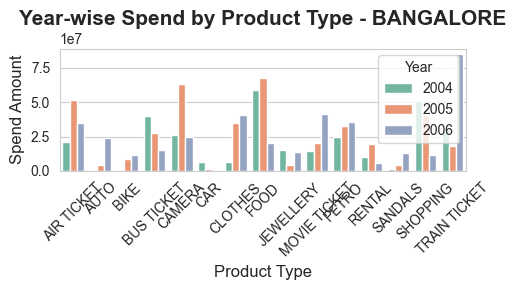

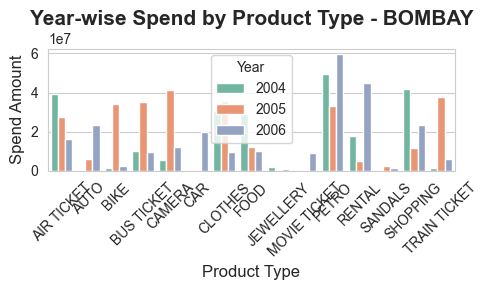

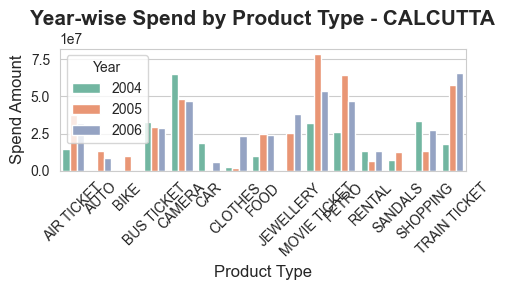

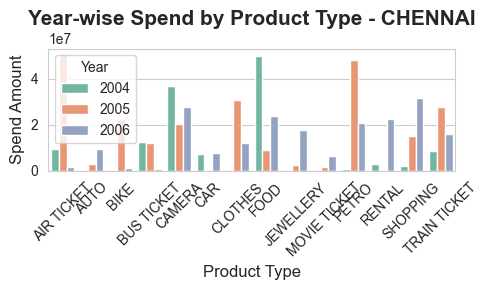

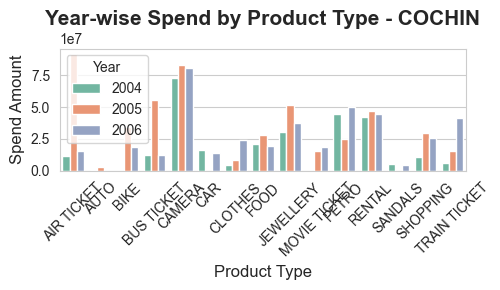

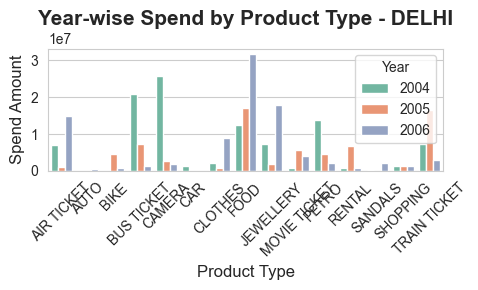

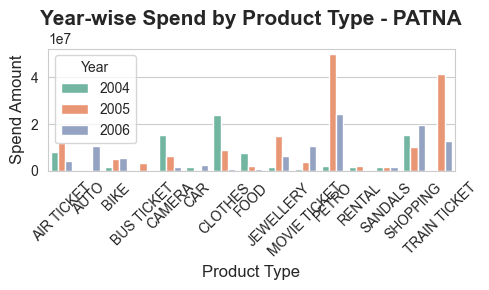

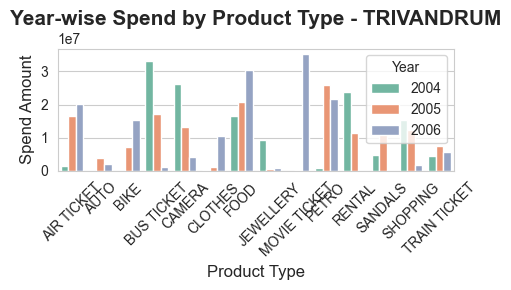

In [92]:
sns.set_style("whitegrid")
sns.set_palette("Set2")   # Try Set1, Set2, Set3, Paired, tab10, Dark2

city_product = (
    df.groupby(['City','Type','Spend_Year'])['Spend_Amount']
      .sum()
      .reset_index()
)

for city in city_product['City'].unique():
    plt.figure(figsize=(5,3))

    sns.barplot(
        data=city_product[city_product['City'] == city],
        x='Type',
        y='Spend_Amount',
        hue='Spend_Year',
        palette='Set2',
        errorbar=None
    )

    plt.title(f'Year-wise Spend by Product Type - {city}', fontsize=15, fontweight='bold')
    plt.xlabel('Product Type', fontsize=12)
    plt.ylabel('Spend Amount', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Year')
    plt.tight_layout()
    plt.show()

4. Create graphs for

a. Monthly comparison of total spends, city wise

b. Comparison of yearly spend on air tickets

c. Comparison of monthly spend for each product (look for any seasonality
that exists in terms of spend)

In [93]:
## A.
total_spend_city = df.groupby(['City','Spend_Month'])['Spend_Amount'].sum().reset_index()
total_spend_city

,City,Spend_Month,Spend_Amount
0,BANGALORE,1,2.308396e+08
1,BANGALORE,2,1.808167e+08
2,BANGALORE,3,1.478226e+08
3,BANGALORE,4,1.088377e+08
4,BANGALORE,5,1.842610e+08
...,...,...,...
91,TRIVANDRUM,8,1.346699e+07
92,TRIVANDRUM,9,5.767975e+06
93,TRIVANDRUM,10,7.710712e+06
94,TRIVANDRUM,11,3.622461e+06


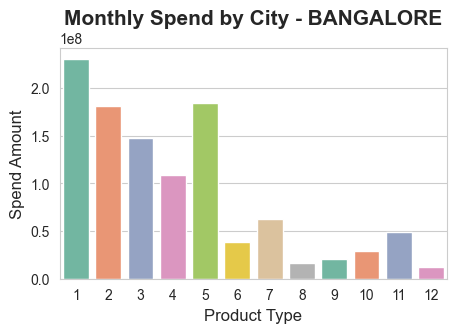

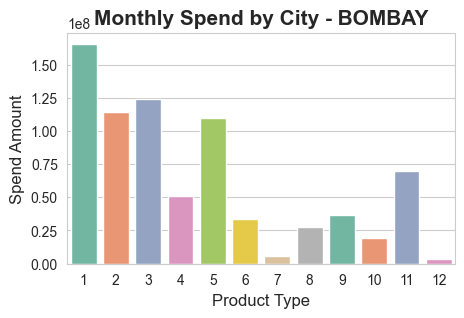

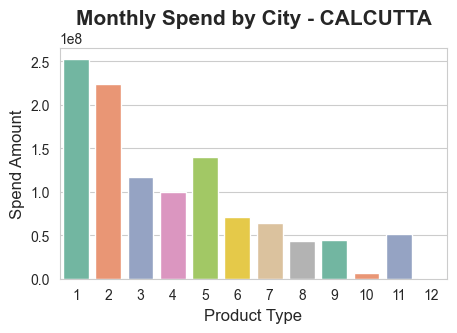

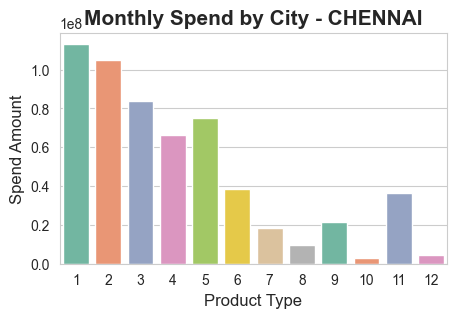

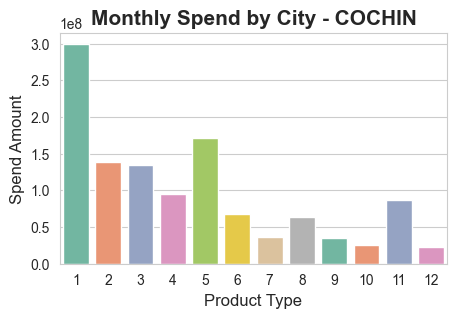

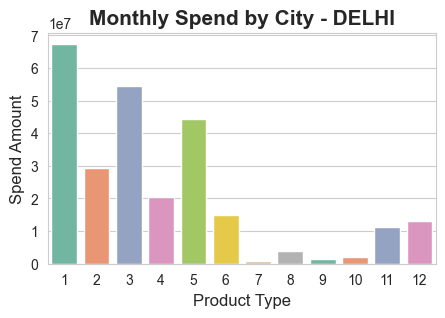

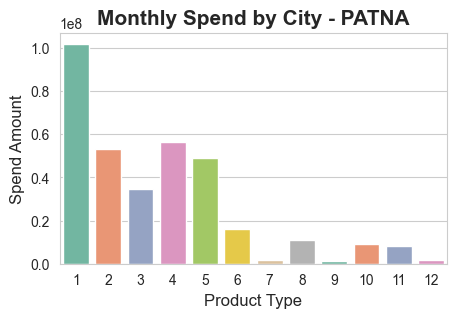

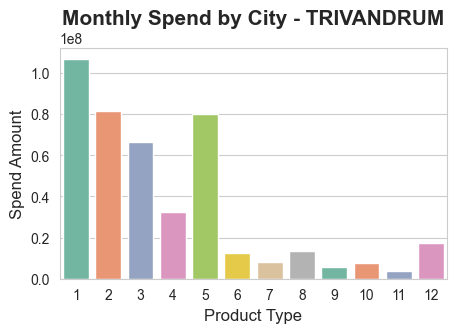

In [94]:
sns.set_style("whitegrid")
sns.set_palette("Set2")   # Try Set1, Set2, Set3, Paired, tab10, Dark2

for city in total_spend_city['City'].unique():
    plt.figure(figsize=(5,3))

    sns.barplot(
        data=total_spend_city[total_spend_city['City'] == city],
        x='Spend_Month',
        y='Spend_Amount',
        palette='Set2',
        errorbar=None
    )

    plt.title(f'Monthly Spend by City - {city}', fontsize=15, fontweight='bold')
    plt.xlabel('Product Type', fontsize=12)
    plt.ylabel('Spend Amount', fontsize=12)
    plt.show()

In [95]:
## B.
air_ticket  = df[df['Type'] == 'AIR TICKET'].groupby(['Type','Spend_Year'])['Spend_Amount'].sum().reset_index()

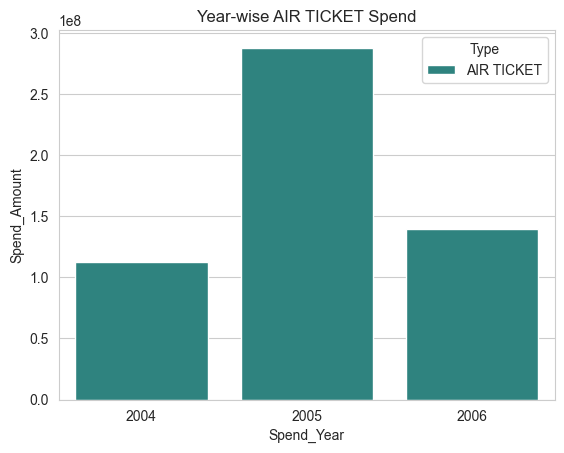

In [96]:
sns.barplot(
    data=air_ticket,
    x='Spend_Year',
    y='Spend_Amount',
    palette='viridis',   # or Set2, Spectral, tab10, husl
    hue='Type'
)

plt.title('Year-wise AIR TICKET Spend')
plt.show()

In [97]:
## C.
## Calculate the spend MOnth Name
df['Spend_Month_Name'] = df['Spend_Date'].dt.month_name()

In [100]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df['Spend_Month_Name'] = pd.Categorical(
    df['Spend_Month_Name'],
    categories=month_order,
    ordered=True
)

In [102]:
## Aggerate the monthly spend
monthly_spend = (
    df.groupby(['Spend_Month_Name', 'Type'])['Spend_Amount']
      .sum()
      .reset_index()
)

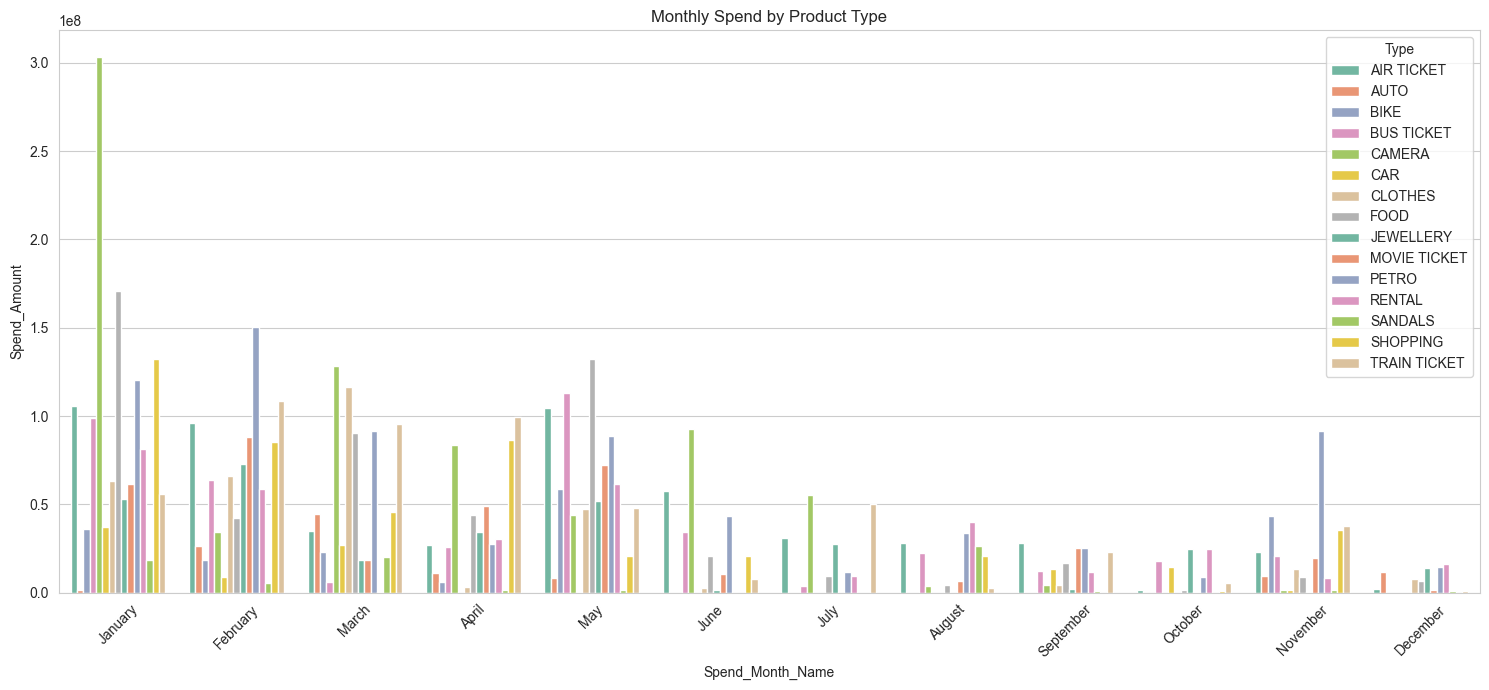

In [105]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=monthly_spend,
    x='Spend_Month_Name',
    y='Spend_Amount',
    hue='Type',
    palette='Set2',
    errorbar=None
)

plt.title('Monthly Spend by Product Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

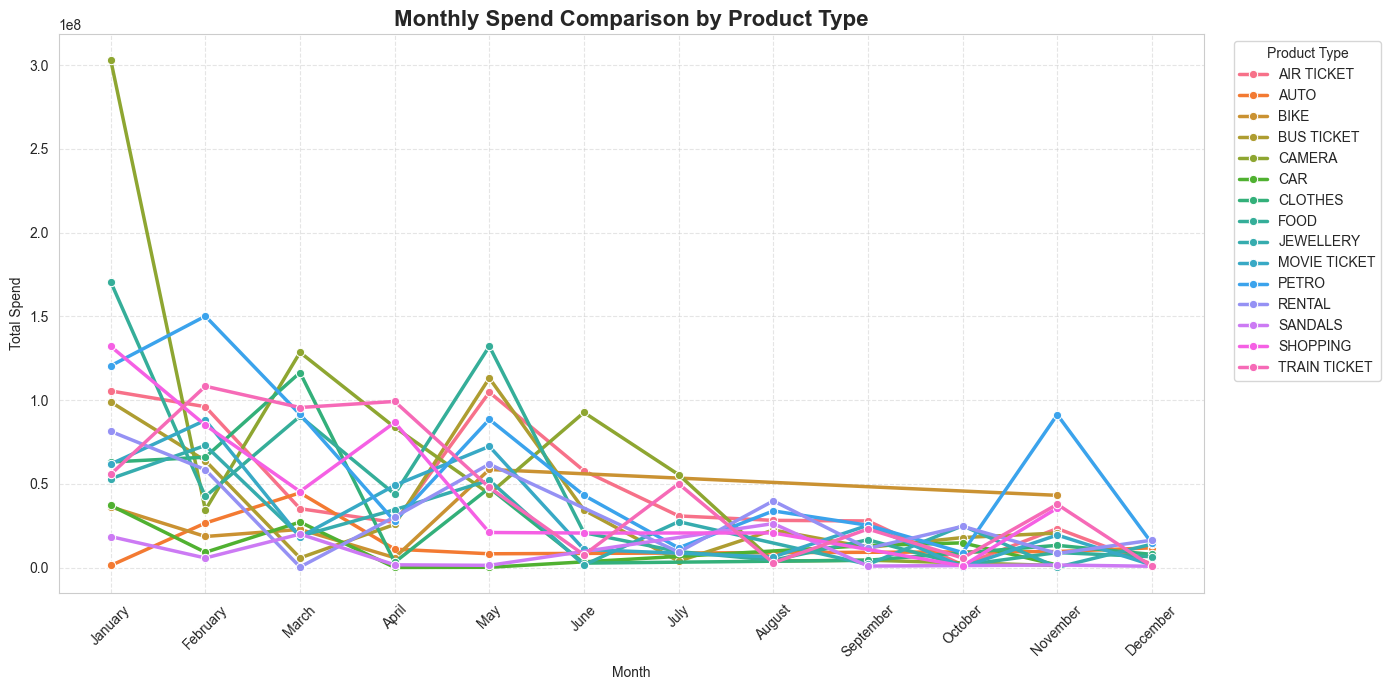

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.lineplot(
    data=monthly_spend,
    x='Spend_Month_Name',
    y='Spend_Amount',
    hue='Type',
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Spend Comparison by Product Type', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Spend')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Product Type', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

Write user defined PYTHON function to perform the following analysis:

You need to find top 10 customers for each city in terms of their repayment amount by 
different products and by different time periods i.e. year or month. The user should be able 
to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the 
function should automatically take these inputs while identifying the top 10 customers.

In [107]:
def top10_customers(df, product, time_period):

    temp = df[df['Product'] == product].copy()

    if time_period.lower() == 'yearly':
        temp['Period'] = temp['Repayment_Date'].dt.year

    elif time_period.lower() == 'monthly':
        temp['Period'] = temp['Repayment_Date'].dt.month_name()

    else:
        print("Please enter 'yearly' or 'monthly'")
        return

    result = (
        temp.groupby(['City', 'Period', 'Customer'])['Repayment_Amount']
            .sum()
            .reset_index()
    )

    result = (
        result.sort_values(
            ['City', 'Period', 'Repayment_Amount'],
            ascending=[True, True, False]
        )
        .groupby(['City', 'Period'])
        .head(10)
    )

    return result

In [109]:
## Top 10 Gold customers yearly
top10_customers(df, 'Gold', 'yearly')
## Top 10 Silver customers monthly
top10_customers(df, 'Silver', 'monthly')
## Top 10 Platinum customers monthly
top10_customers(df, 'Platinum', 'monthly')

,City,Period,Customer,Repayment_Amount
